In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
print(df.shape)

df.info()

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [6]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [7]:
def development(gdpp):
    if gdpp < 3000:
        return "Low"
    elif gdpp < 12000:
        return "Medium"
    else:
        return "High"

df["Development"] = df["gdpp"].apply(development)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Development
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,Low
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,Medium
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,Medium
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,Medium
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,High


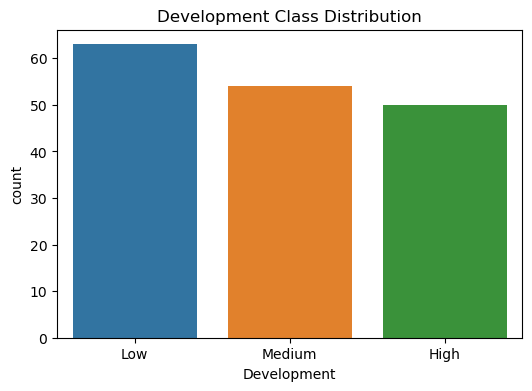

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="Development", data=df)
plt.title("Development Class Distribution")
plt.show()

In [9]:
encoder = LabelEncoder()

df["Development"] = encoder.fit_transform(df["Development"])

print(encoder.classes_)

['High' 'Low' 'Medium']


In [10]:
df = df.drop("country", axis=1)

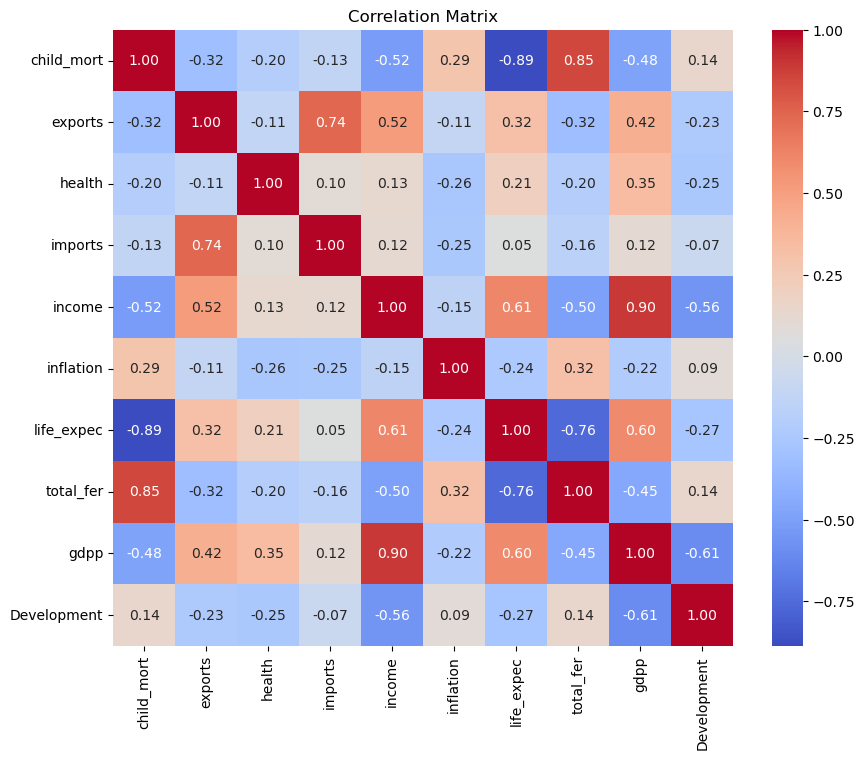

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [12]:
X = df.drop("Development", axis=1)

y = df["Development"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [15]:
print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (133, 9)
Testing Shape : (34, 9)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [17]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.7941176470588235
              precision    recall  f1-score   support

           0       1.00      0.60      0.75        10
           1       1.00      0.77      0.87        13
           2       0.61      1.00      0.76        11

    accuracy                           0.79        34
   macro avg       0.87      0.79      0.79        34
weighted avg       0.87      0.79      0.80        34



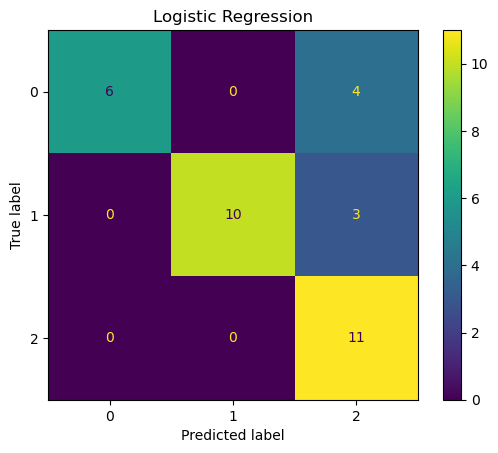

In [18]:
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.title("Logistic Regression")

plt.show()

In [19]:
nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.8823529411764706
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       1.00      0.85      0.92        13
           2       0.73      1.00      0.85        11

    accuracy                           0.88        34
   macro avg       0.91      0.88      0.88        34
weighted avg       0.91      0.88      0.89        34



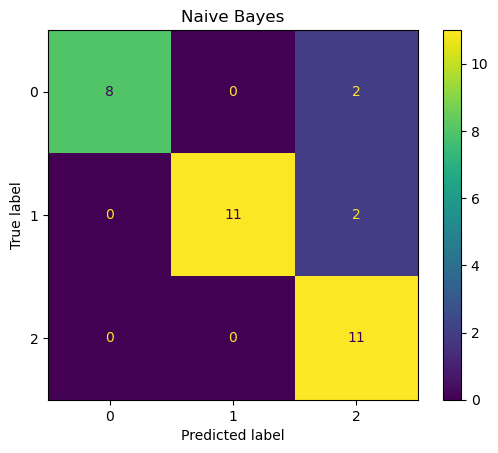

In [20]:
cm = confusion_matrix(y_test, nb_pred)

ConfusionMatrixDisplay(cm).plot()

plt.title("Naive Bayes")

plt.show()

In [21]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.8235294117647058
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.83      0.77      0.80        13
           2       0.71      0.91      0.80        11

    accuracy                           0.82        34
   macro avg       0.85      0.83      0.83        34
weighted avg       0.84      0.82      0.83        34



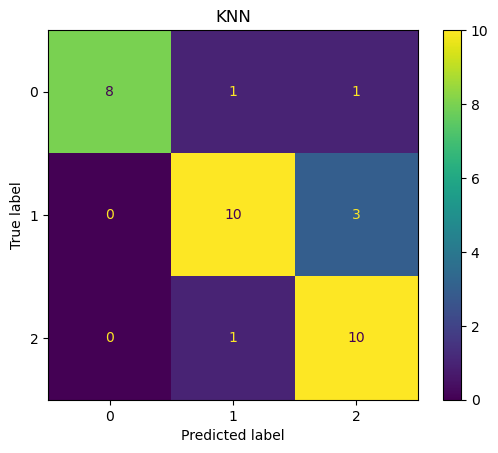

In [22]:
cm = confusion_matrix(y_test, knn_pred)

ConfusionMatrixDisplay(cm).plot()

plt.title("KNN")

plt.show()

In [23]:
svm = SVC(kernel="rbf", random_state=42)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.7647058823529411
              precision    recall  f1-score   support

           0       1.00      0.60      0.75        10
           1       0.82      0.69      0.75        13
           2       0.65      1.00      0.79        11

    accuracy                           0.76        34
   macro avg       0.82      0.76      0.76        34
weighted avg       0.82      0.76      0.76        34



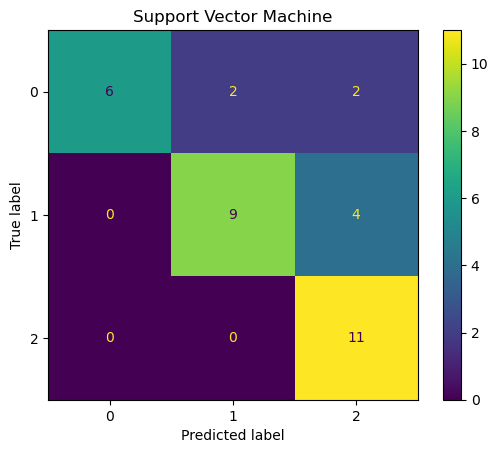

In [24]:
cm = confusion_matrix(y_test, svm_pred)

ConfusionMatrixDisplay(cm).plot()

plt.title("Support Vector Machine")

plt.show()

In [25]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        11

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



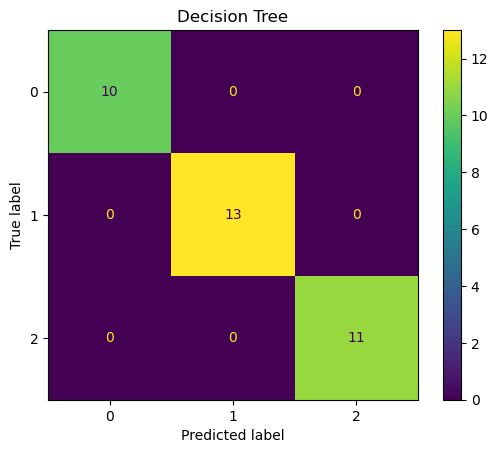

In [26]:
cm = confusion_matrix(y_test, dt_pred)

ConfusionMatrixDisplay(cm).plot()

plt.title("Decision Tree")

plt.show()

In [27]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       1.00      1.00      1.00        13
           2       0.92      1.00      0.96        11

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



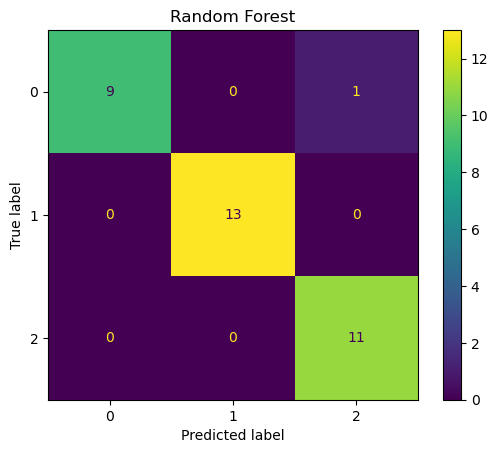

In [28]:
cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(cm).plot()

plt.title("Random Forest")

plt.show()

In [29]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "KNN",
        "SVM",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy
4,Decision Tree,1.000000
5,Random Forest,0.970588
1,Naive Bayes,0.882353
2,KNN,0.823529
0,Logistic Regression,0.794118
3,SVM,0.764706


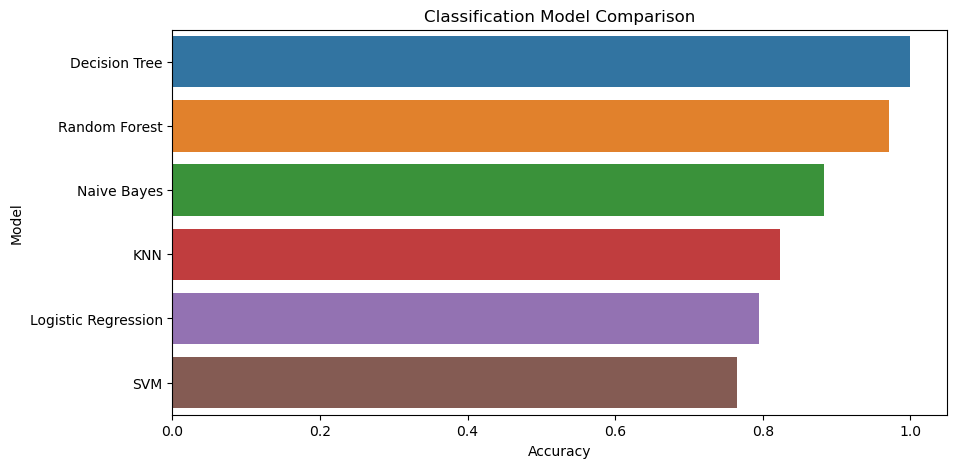

In [30]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=results
)

plt.title("Classification Model Comparison")

plt.show()

In [31]:
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [32]:
ada = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

print("AdaBoost Accuracy:",
      accuracy_score(y_test, ada_pred))

print(classification_report(y_test, ada_pred))

AdaBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        11

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [33]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, gb_pred))

print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        11

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [34]:
xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       1.00      1.00      1.00        13
           2       0.92      1.00      0.96        11

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



In [36]:
lgb = LGBMClassifier(random_state=42)

lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_test)

print("LightGBM Accuracy:",
      accuracy_score(y_test, lgb_pred))

print(classification_report(y_test, lgb_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000228 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 397
[LightGBM] [Info] Number of data points in the train set: 133, number of used features: 9
[LightGBM] [Info] Start training from score -1.201470
[LightGBM] [Info] Start training from score -0.978326
[LightGBM] [Info] Start training from score -1.129149
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

In [37]:
estimators = [
    ('rf', RandomForestClassifier(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier())
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stack.fit(X_train, y_train)

stack_pred = stack.predict(X_test)

print("Stacking Accuracy:",
      accuracy_score(y_test, stack_pred))

print(classification_report(y_test, stack_pred))

Stacking Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       1.00      1.00      1.00        13
           2       0.85      1.00      0.92        11

    accuracy                           0.94        34
   macro avg       0.95      0.93      0.94        34
weighted avg       0.95      0.94      0.94        34



In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
8,gdpp,0.421814
4,income,0.259974
0,child_mort,0.119456
6,life_expec,0.090222
7,total_fer,0.047683
5,inflation,0.021194
1,exports,0.019201
2,health,0.013378
3,imports,0.007077


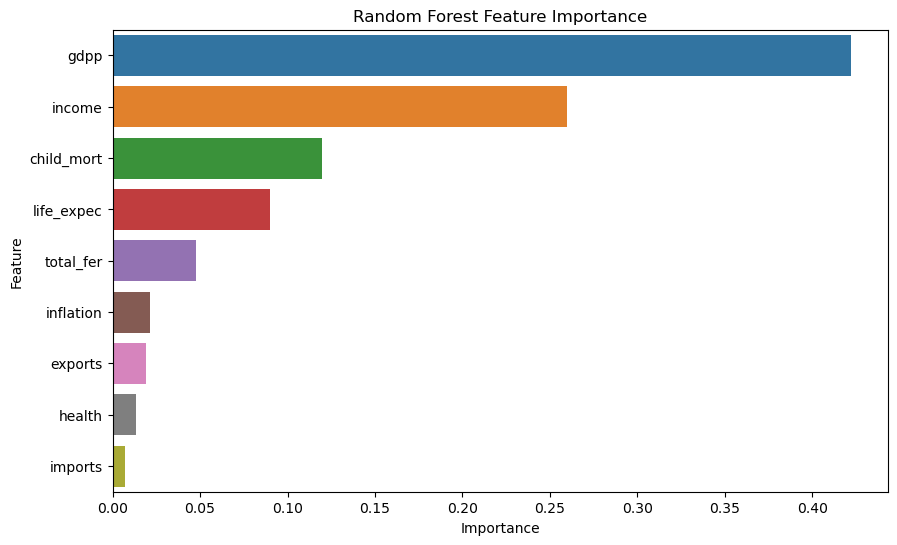

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [40]:
ensemble_results = pd.DataFrame({

    "Model":[
        "AdaBoost",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "Stacking"
    ],

    "Accuracy":[
        accuracy_score(y_test, ada_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgb_pred),
        accuracy_score(y_test, stack_pred)
    ]

})

ensemble_results = ensemble_results.sort_values(
    by="Accuracy",
    ascending=False
)

ensemble_results

,Model,Accuracy
0,AdaBoost,1.000000
1,Gradient Boosting,1.000000
3,LightGBM,1.000000
2,XGBoost,0.970588
4,Stacking,0.941176


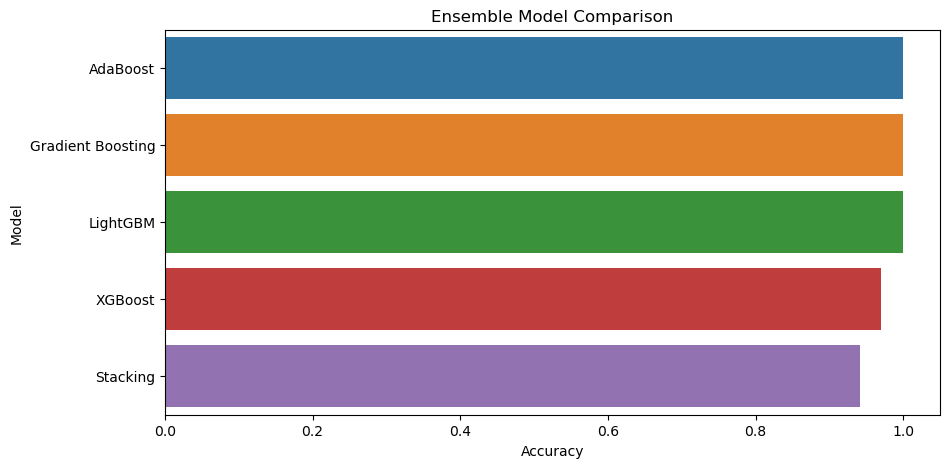

In [41]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=ensemble_results,
    x="Accuracy",
    y="Model"
)

plt.title("Ensemble Model Comparison")

plt.show()

In [42]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

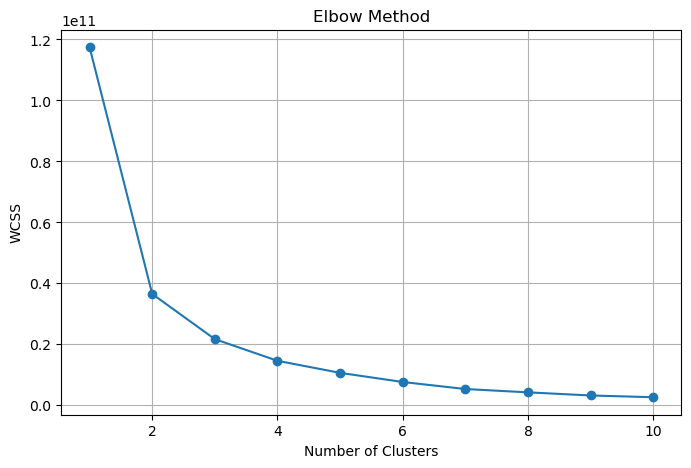

In [43]:
wcss = []

for i in range(1, 11):
    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [44]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

df["KMeans_Cluster"] = kmeans_labels

print(df[["KMeans_Cluster"]].head())

   KMeans_Cluster
0               1
1               1
2               1
3               1
4               1


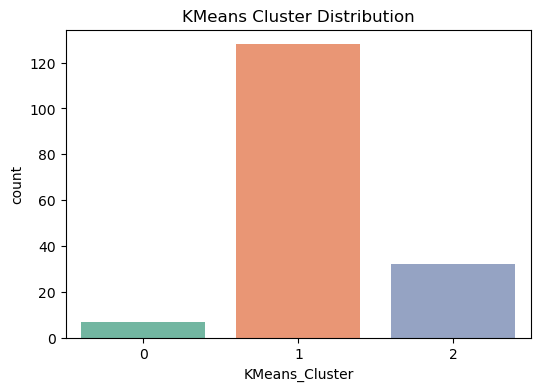

In [45]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="KMeans_Cluster",
    data=df,
    palette="Set2"
)

plt.title("KMeans Cluster Distribution")
plt.show()

In [46]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X)

df["DBSCAN_Cluster"] = db_labels

print(df[["DBSCAN_Cluster"]].head())

   DBSCAN_Cluster
0              -1
1              -1
2              -1
3              -1
4              -1


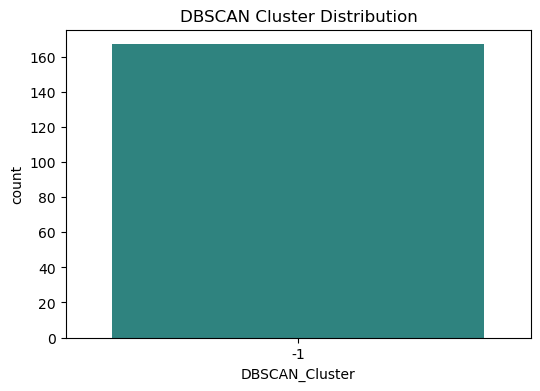

In [47]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="DBSCAN_Cluster",
    data=df,
    palette="viridis"
)

plt.title("DBSCAN Cluster Distribution")
plt.show()

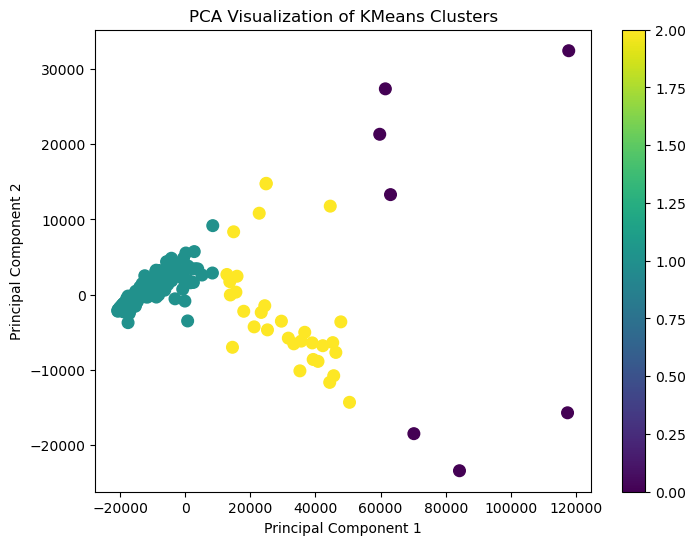

In [48]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap="viridis",
    s=70
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of KMeans Clusters")

plt.colorbar()

plt.show()

In [49]:
score = silhouette_score(X, kmeans_labels)

print("Silhouette Score :", score)

Silhouette Score : 0.7003508054481694


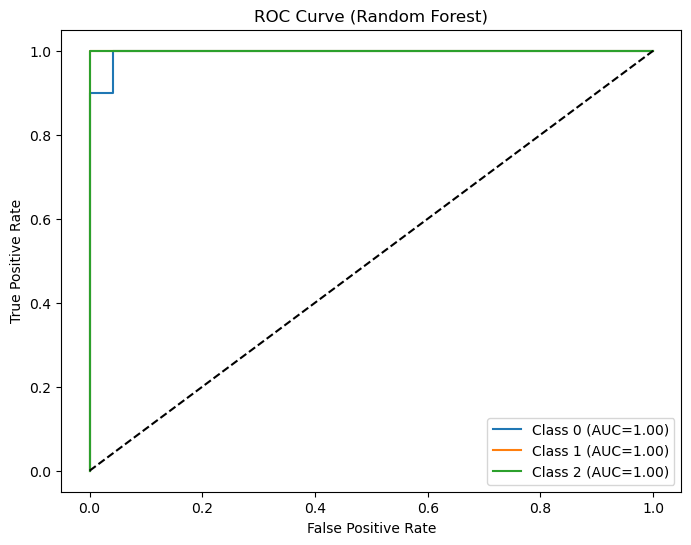

In [50]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

rf_prob = rf.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(3):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:,i],
        rf_prob[:,i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} (AUC={roc_auc:.2f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest)")
plt.legend()

plt.show()

In [51]:
comparison = pd.DataFrame({

"Model":[
"Logistic Regression",
"Naive Bayes",
"KNN",
"SVM",
"Decision Tree",
"Random Forest",
"AdaBoost",
"Gradient Boosting",
"XGBoost",
"LightGBM",
"Stacking"
],

"Accuracy":[
accuracy_score(y_test, lr_pred),
accuracy_score(y_test, nb_pred),
accuracy_score(y_test, knn_pred),
accuracy_score(y_test, svm_pred),
accuracy_score(y_test, dt_pred),
accuracy_score(y_test, rf_pred),
accuracy_score(y_test, ada_pred),
accuracy_score(y_test, gb_pred),
accuracy_score(y_test, xgb_pred),
accuracy_score(y_test, lgb_pred),
accuracy_score(y_test, stack_pred)
]

})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
4,Decision Tree,1.000000
6,AdaBoost,1.000000
7,Gradient Boosting,1.000000
9,LightGBM,1.000000
5,Random Forest,0.970588
8,XGBoost,0.970588
10,Stacking,0.941176
1,Naive Bayes,0.882353
2,KNN,0.823529
0,Logistic Regression,0.794118


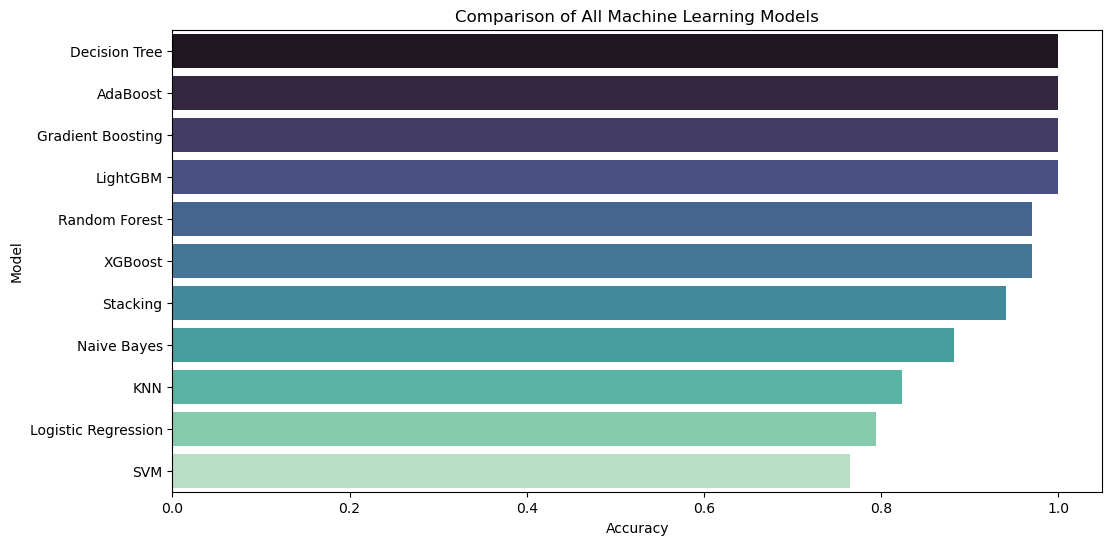

In [52]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison,
    x="Accuracy",
    y="Model",
    palette="mako"
)

plt.title("Comparison of All Machine Learning Models")

plt.show()

In [53]:
comparison.to_csv(
    "Final_Model_Comparison.csv",
    index=False
)

print("CSV Saved Successfully")

CSV Saved Successfully


In [54]:
best = comparison.iloc[0]

print("=================================")
print("BEST PERFORMING MODEL")
print("=================================")

print(best)

BEST PERFORMING MODEL
Model       Decision Tree
Accuracy              1.0
Name: 4, dtype: object


# Conclusion: Week 3 Machine Learning Project Completed Successfully.

Tasks Completed:
✔ Data Preprocessing
✔ Exploratory Data Analysis
✔ Feature Engineering
✔ Logistic Regression
✔ Naive Bayes
✔ KNN
✔ SVM
✔ Decision Tree
✔ Random Forest
✔ AdaBoost
✔ Gradient Boosting
✔ XGBoost
✔ LightGBM
✔ Stacking Classifier
✔ Feature Importance
✔ KMeans Clustering
✔ DBSCAN
✔ PCA Visualization
✔ Elbow Method
✔ ROC Curve
✔ Silhouette Score
✔ Model Comparison